# Has the Structure of Risk in Financial Markets Changed Since COVID-19?

This notebook produces all empirical results supporting the project report.  
It uses only `Data.xlsx` and requires no external dataset.

**Assets:** S&P 500, Eurostoxx 50, Hang Seng, Oil futures, Gold, US IG Bonds, US HY Bonds  
**Period:** 2010 – April 2026  
**COVID breakpoint:** March 2020


---
## Section 1 — Setup and Data Loading

In [197]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
from scipy.stats import skew, kurtosis, norm
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_PATH   = Path('Data.xlsx')
FIG_DIR     = Path('Figures');  FIG_DIR.mkdir(exist_ok=True)
TAB_DIR     = Path('Tables');   TAB_DIR.mkdir(exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────
ANNUALIZATION  = 252
SAMPLE_START   = pd.Timestamp('2010-01-01')   # start of analysis window
COVID_DATE     = pd.Timestamp('2020-03-01')   # breakpoint
ASSETS         = ['S&P500', 'Eurostoxx 50', 'Hang Seng',
                  'Oil futures', 'Gold', 'US IG Bonds', 'US HY Bonds']

# ── Load prices ────────────────────────────────────────────────────────────
raw = pd.read_excel(DATA_PATH, sheet_name='Feuil1')
raw = raw.rename(columns={raw.columns[0]: 'Date'}).set_index('Date')
raw.index = pd.to_datetime(raw.index)
raw = raw.sort_index()

prices = raw[ASSETS].ffill()
prices = prices.where(prices > 0).ffill().dropna(how='any')
prices = prices[prices.index >= SAMPLE_START]

# ── Log returns (daily) ────────────────────────────────────────────────────
returns = np.log(prices).diff().dropna()

# ── Pre / Post COVID splits ────────────────────────────────────────────────
ret_pre  = returns[returns.index <  COVID_DATE]
ret_post = returns[returns.index >= COVID_DATE]

print(f'Full sample : {returns.index[0].date()} → {returns.index[-1].date()}  ({len(returns):,} obs)')
print(f'Pre-COVID   : {ret_pre.index[0].date()} → {ret_pre.index[-1].date()}  ({len(ret_pre):,} obs)')
print(f'Post-COVID  : {ret_post.index[0].date()} → {ret_post.index[-1].date()}  ({len(ret_post):,} obs)')
prices.tail(3)

Full sample : 2010-01-04 → 2026-04-24  (4,312 obs)
Pre-COVID   : 2010-01-04 → 2020-02-29  (2,686 obs)
Post-COVID  : 2020-03-02 → 2026-04-24  (1,626 obs)


,S&P500,Eurostoxx 50,Hang Seng,Oil futures,Gold,US IG Bonds,US HY Bonds
Date,,,,,,,
2026-04-22,7137.8999,5906.2202,26163.2402,92.96,4739.8999,3613.8870,2696.9160
2026-04-23,7108.3999,5894.7300,25915.1992,95.85,4694.1401,3608.3889,2694.0430
2026-04-24,7165.0801,5883.4800,25978.0703,94.40,4709.5000,3612.0129,2695.6079


---
## Section 2 — Descriptive Statistics and Stylized Facts

Before any modelling, we document the main statistical properties of each return series — mean, volatility, skewness, excess kurtosis and tail behaviour — and compare pre- vs post-COVID.

In [198]:
# ── Summary statistics table ───────────────────────────────────────────────
def summary_stats(ret):
    ann = ANNUALIZATION
    df = pd.DataFrame({
        'Ann. Return (%)' : ret.mean() * ann * 100,
        'Ann. Vol (%)' : ret.std() * np.sqrt(ann) * 100,
        'Sharpe' : (ret.mean() * ann) / (ret.std() * np.sqrt(ann)),
        'Skewness' : ret.apply(skew),
        'Exc. Kurtosis' : ret.apply(kurtosis),
        'Min (%)' : ret.min() * 100,
        'Max (%)' : ret.max() * 100,
    })
    return df.round(3)

stats_full = summary_stats(returns)
stats_pre  = summary_stats(ret_pre)
stats_post = summary_stats(ret_post)

print('=== Full sample ===')
display(stats_full)

print('\n=== Pre-COVID ===')
display(stats_pre)

print('\n=== Post-COVID ===')
display(stats_post)

stats_full.to_csv(TAB_DIR / 'descriptive_stats_full.csv')
stats_pre.to_csv(TAB_DIR  / 'descriptive_stats_pre.csv')
stats_post.to_csv(TAB_DIR / 'descriptive_stats_post.csv')

=== Full sample ===


,Ann. Return (%),Ann. Vol (%),Sharpe,Skewness,Exc. Kurtosis,Min (%),Max (%)
S&P500,10.872,16.893,0.644,-0.616,14.298,-12.765,9.089
Eurostoxx 50,4.005,19.490,0.205,-0.465,8.274,-13.241,9.847
Hang Seng,1.005,20.216,0.050,-0.367,6.938,-14.183,8.693
Oil futures,1.014,42.851,0.024,-2.593,75.616,-60.168,31.963
Gold,8.513,15.925,0.535,-0.649,6.648,-9.512,5.942
US IG Bonds,3.801,5.053,0.752,-0.792,8.776,-3.830,1.977
US HY Bonds,5.924,4.711,1.257,-1.598,31.803,-3.684,3.324



=== Pre-COVID ===


,Ann. Return (%),Ann. Vol (%),Sharpe,Skewness,Exc. Kurtosis,Min (%),Max (%)
S&P500,9.141,14.520,0.630,-0.556,5.021,-6.896,4.840
Eurostoxx 50,1.088,19.281,0.056,-0.188,4.889,-9.011,9.847
Hang Seng,1.669,17.473,0.095,-0.316,2.630,-6.018,5.519
Oil futures,-5.373,32.039,-0.168,0.059,3.753,-10.794,13.694
Gold,3.454,14.975,0.231,-0.649,6.601,-9.512,4.581
US IG Bonds,5.448,4.081,1.335,-0.371,1.529,-1.524,0.933
US HY Bonds,6.628,3.569,1.857,-1.086,7.987,-1.664,1.197



=== Post-COVID ===


,Ann. Return (%),Ann. Vol (%),Sharpe,Skewness,Exc. Kurtosis,Min (%),Max (%)
S&P500,13.731,20.217,0.679,-0.626,15.870,-12.765,9.089
Eurostoxx 50,8.824,19.833,0.445,-0.888,13.301,-13.241,8.834
Hang Seng,-0.090,24.078,-0.004,-0.373,7.523,-14.183,8.693
Oil futures,11.565,56.342,0.205,-3.069,65.784,-60.168,31.963
Gold,16.871,17.374,0.971,-0.663,6.340,-9.375,5.942
US IG Bonds,1.079,6.338,0.170,-0.854,8.251,-3.830,1.977
US HY Bonds,4.761,6.151,0.774,-1.531,26.677,-3.684,3.324


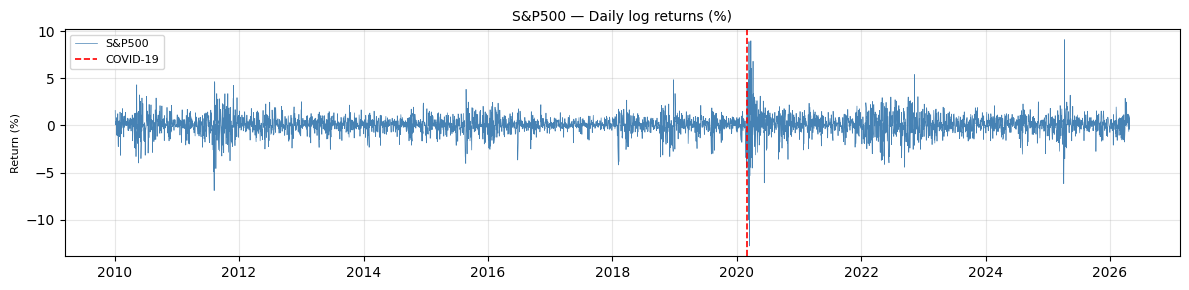

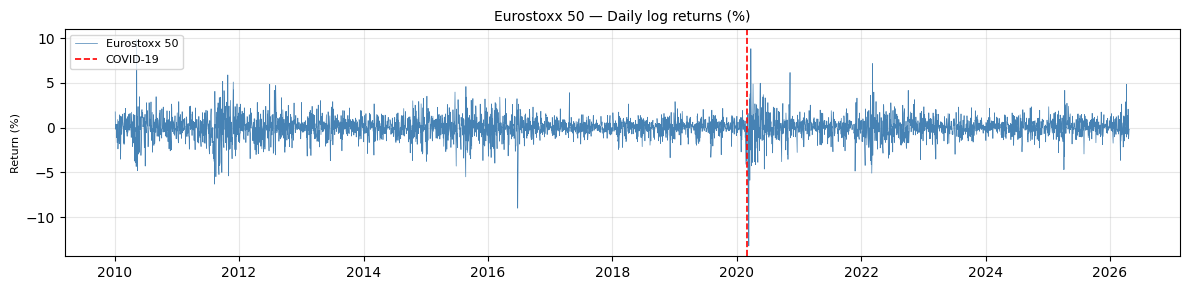

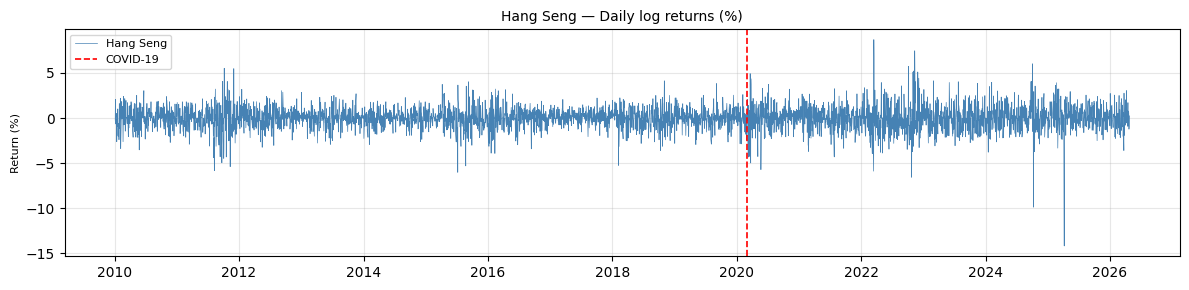

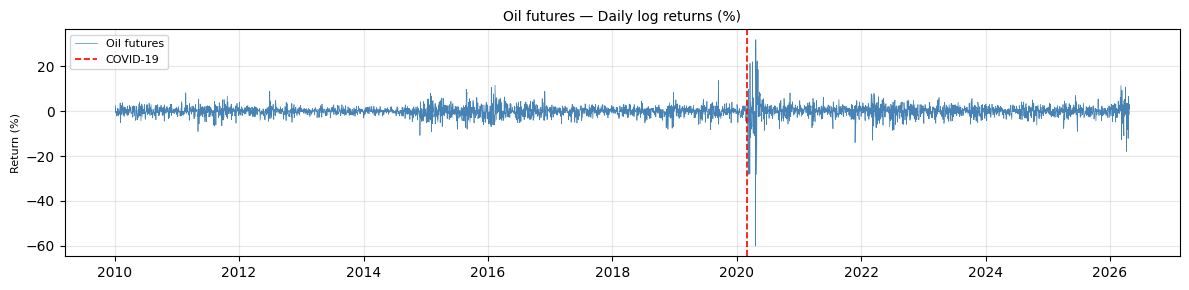

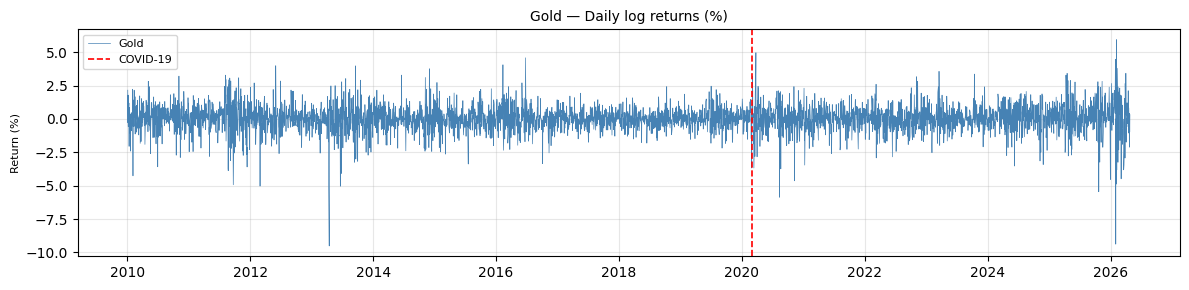

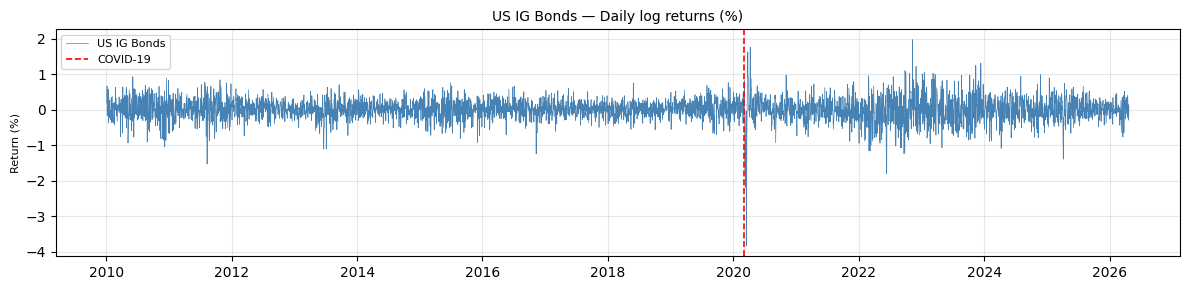

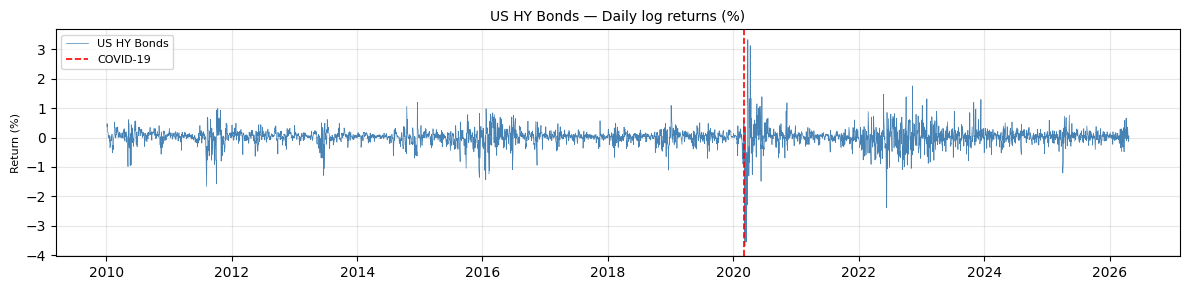

In [199]:
# ── Return series — all assets ──────────────────────────────────────────────
colors = {
    'S&P500'      : 'steelblue',
    'Eurostoxx 50': 'steelblue',
    'Hang Seng'   : 'steelblue',
    'Oil futures' : 'steelblue',
    'Gold'        : 'steelblue',
    'US IG Bonds' : 'steelblue',
    'US HY Bonds' : 'steelblue'
}

for col in ASSETS:
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(returns.index, returns[col] * 100, 
            linewidth=0.5, color=colors[col], label=col)
    ax.axvline(COVID_DATE, color='red', linestyle='--', 
               linewidth=1.2, label='COVID-19')
    ax.set_title(f'{col} — Daily log returns (%)', fontsize=10)
    ax.set_ylabel('Return (%)', fontsize=8)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    filename = col.replace(' ', '_').replace('&', 'and').replace('/', '_')
    plt.savefig(FIG_DIR / f'returns_{filename}.png', dpi=200)
    plt.show()

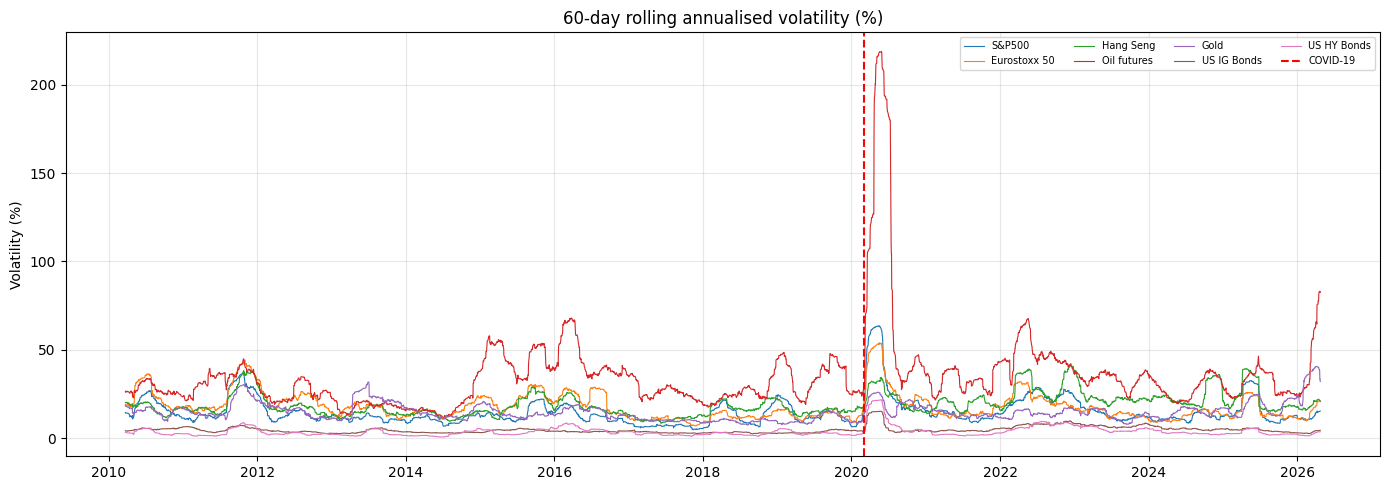

In [200]:
# ── Volatility clustering: rolling 60-day vol ──────────────────────────────
rolling_vol = returns.rolling(60).std() * np.sqrt(ANNUALIZATION) * 100

fig, ax = plt.subplots(figsize=(14, 5))
for col in ASSETS:
    ax.plot(rolling_vol.index, rolling_vol[col], linewidth=0.8, label=col)
ax.axvline(COVID_DATE, color='red', linestyle='--', linewidth=1.5, label='COVID-19')
ax.set_title('60-day rolling annualised volatility (%)')
ax.set_ylabel('Volatility (%)')
ax.legend(fontsize=7, ncol=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rolling_vol_all.png', dpi=200)
plt.show()

In [201]:
# ── ARCH-LM test for volatility clustering (Engle 1982) ────────────────────
arch_results = {}
for col in ASSETS:
    r = returns[col].dropna()
    stat, pval, _, _ = het_arch(r, nlags=10)
    arch_results[col] = {'LM stat': round(stat, 2), 'p-value': round(pval, 4)}

arch_table = pd.DataFrame(arch_results).T
print('ARCH-LM test (10 lags) — H0: no ARCH effects')
display(arch_table)
arch_table.to_csv(TAB_DIR / 'arch_lm_test.csv')

ARCH-LM test (10 lags) — H0: no ARCH effects


,LM stat,p-value
S&P500,1321.33,0.0
Eurostoxx 50,594.27,0.0
Hang Seng,164.77,0.0
Oil futures,553.98,0.0
Gold,306.07,0.0
US IG Bonds,1025.11,0.0
US HY Bonds,1423.87,0.0


---
## Section 3 — GARCH(1,1) Volatility Modelling

We estimate a Gaussian GARCH(1,1) on each asset. The recursion is:

$$\sigma^2_t = \omega + \alpha \varepsilon^2_{t-1} + \beta \sigma^2_{t-1}$$

Parameters are estimated by quasi-maximum likelihood. We then compare conditional volatility pre- vs post-COVID.

In [202]:
# ── GARCH(1,1) Gaussian QMLE — robust multi-start ─────────────────────────
def garch11_nll(params, eps):
    omega, alpha, beta = params
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
        return 1e10
    T = len(eps)
    sigma2 = np.empty(T)
    sigma2[0] = np.var(eps)
    for t in range(1, T):
        sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
    ll = -0.5 * (np.log(2 * np.pi) + np.log(sigma2) + eps**2 / sigma2)
    return -ll.sum()

def fit_garch11(series):
    eps     = series.values
    var_eps = np.var(eps)

    # Multiple starting points to avoid local optima
    starts = [
        [var_eps * 0.05, 0.10, 0.85],
        [var_eps * 0.01, 0.05, 0.93],
        [var_eps * 0.10, 0.15, 0.80],
        [var_eps * 0.05, 0.08, 0.90],
        [var_eps * 0.02, 0.12, 0.82],
    ]
    bounds      = [(1e-9, var_eps), (1e-6, 0.3), (0.5, 0.999)]
    constraints = [{'type': 'ineq', 'fun': lambda p: 0.999 - p[1] - p[2]}]

    best_res, best_nll = None, np.inf
    for x0 in starts:
        try:
            res = minimize(garch11_nll, x0, args=(eps,), method='SLSQP',
                           bounds=bounds, constraints=constraints,
                           options={'maxiter': 5000, 'ftol': 1e-14})
            if res.fun < best_nll:
                best_nll = res.fun
                best_res = res
        except Exception:
            pass

    omega, alpha, beta = best_res.x
    T      = len(eps)
    sigma2 = np.empty(T)
    sigma2[0] = var_eps
    for t in range(1, T):
        sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]

    return {'omega': omega, 'alpha': alpha, 'beta': beta,
            'persistence': alpha + beta,
            'long_run_vol': np.sqrt(omega / (1 - alpha - beta)) * np.sqrt(ANNUALIZATION) * 100,
            'sigma2': pd.Series(sigma2, index=series.index)}

garch_results = {col: fit_garch11(returns[col]) for col in ASSETS}
print('GARCH(1,1) estimated — parameters:')
param_table = pd.DataFrame({
    col: {'omega': round(g['omega'], 8),
          'alpha': round(g['alpha'], 4),
          'beta' : round(g['beta'],  4),
          'persistence': round(g['persistence'], 4),
          'LR vol (%)': round(g['long_run_vol'], 2)}
    for col, g in garch_results.items()
}).T
display(param_table)
param_table.to_csv(TAB_DIR / 'garch_parameters.csv')


GARCH(1,1) estimated — parameters:


,omega,alpha,beta,persistence,LR vol (%)
S&P500,5.660000e-06,0.1000,0.8500,0.9500,16.89
Eurostoxx 50,7.250000e-06,0.1020,0.8465,0.9485,18.84
Hang Seng,7.520000e-06,0.0899,0.8651,0.9550,20.52
Oil futures,7.280000e-06,0.0500,0.9300,0.9800,30.30
Gold,3.440000e-06,0.0703,0.8955,0.9658,15.93
US IG Bonds,1.000000e-07,0.0500,0.9300,0.9800,3.57
US HY Bonds,1.800000e-07,0.1200,0.8200,0.9400,2.72


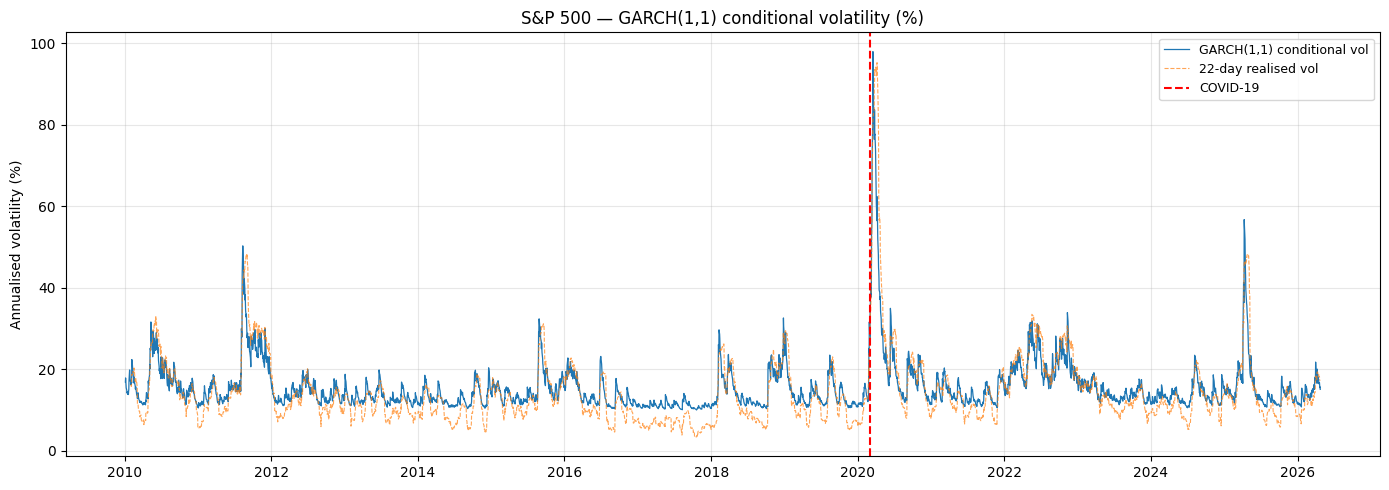

In [203]:
# ── GARCH conditional vol: pre vs post COVID — S&P 500 ─────────────────────
sp_vol = np.sqrt(garch_results['S&P500']['sigma2']) * np.sqrt(ANNUALIZATION) * 100
rv_proxy = returns['S&P500'].rolling(22).std() * np.sqrt(ANNUALIZATION) * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sp_vol, label='GARCH(1,1) conditional vol', linewidth=0.9)
ax.plot(rv_proxy, label='22-day realised vol', linewidth=0.8, alpha=0.7, linestyle='--')
ax.axvline(COVID_DATE, color='red', linestyle='--', linewidth=1.5, label='COVID-19')
ax.set_title('S&P 500 — GARCH(1,1) conditional volatility (%)')
ax.set_ylabel('Annualised volatility (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'garch_vol_sp500.png', dpi=200)
plt.show()

In [204]:
# ── Average conditional vol: pre vs post COVID for all assets ──────────────
vol_compare = pd.DataFrame({
    'Pre-COVID avg vol (%)' : {
        col: np.sqrt(garch_results[col]['sigma2'][ret_pre.index].mean()) * np.sqrt(ANNUALIZATION) * 100
        for col in ASSETS},
    'Post-COVID avg vol (%)': {
        col: np.sqrt(garch_results[col]['sigma2'][ret_post.index].mean()) * np.sqrt(ANNUALIZATION) * 100
        for col in ASSETS},
}).round(2)
vol_compare['Change (pp)'] = (vol_compare['Post-COVID avg vol (%)'] -
                               vol_compare['Pre-COVID avg vol (%)']).round(2)
print('Average GARCH conditional volatility: pre vs post COVID')
display(vol_compare)
vol_compare.to_csv(TAB_DIR / 'vol_pre_post_covid.csv')

Average GARCH conditional volatility: pre vs post COVID


,Pre-COVID avg vol (%),Post-COVID avg vol (%),Change (pp)
S&P500,15.32,19.24,3.92
Eurostoxx 50,19.10,19.57,0.47
Hang Seng,18.54,22.95,4.41
Oil futures,31.60,49.85,18.25
Gold,15.28,16.94,1.66
US IG Bonds,3.96,5.68,1.72
US HY Bonds,3.32,5.28,1.96


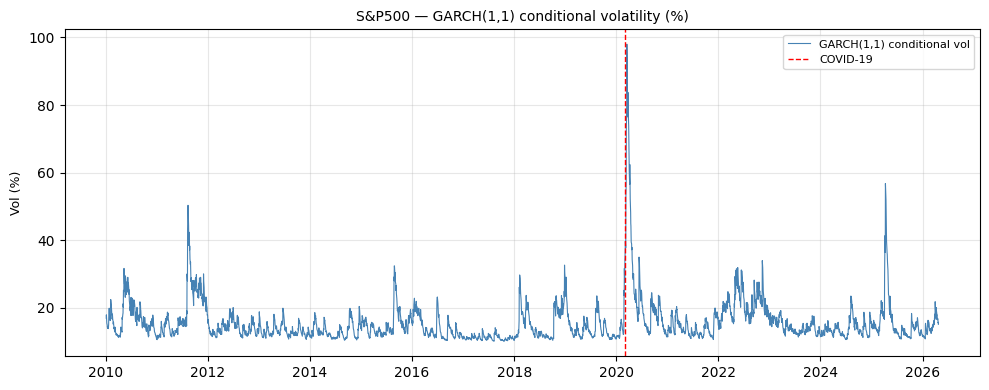

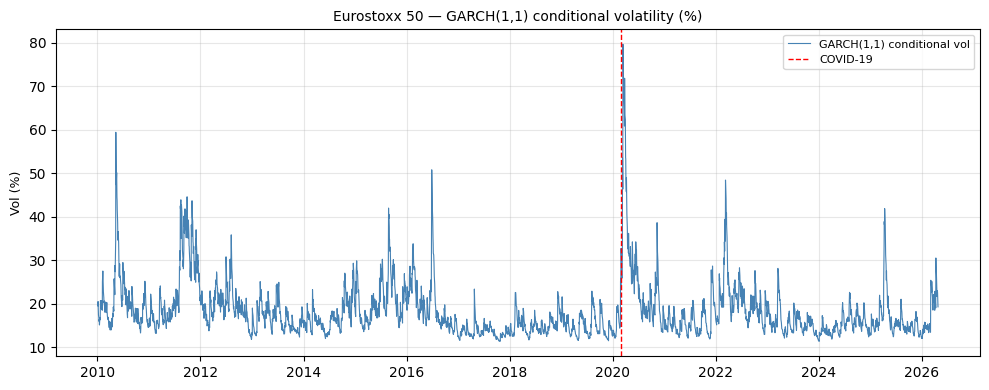

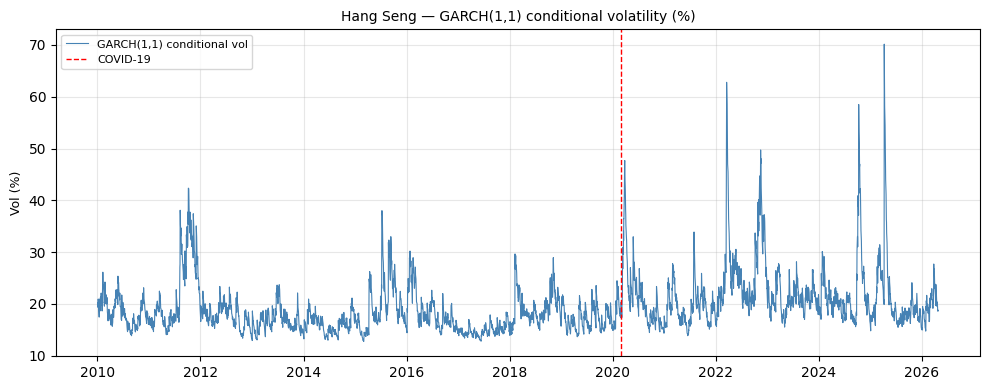

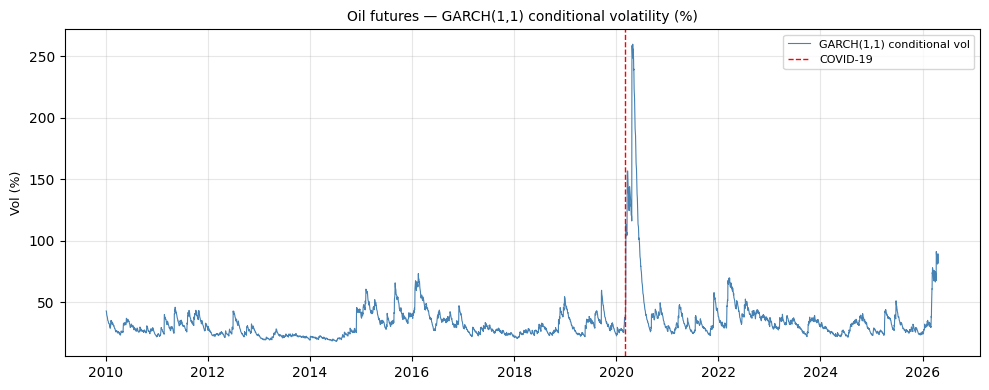

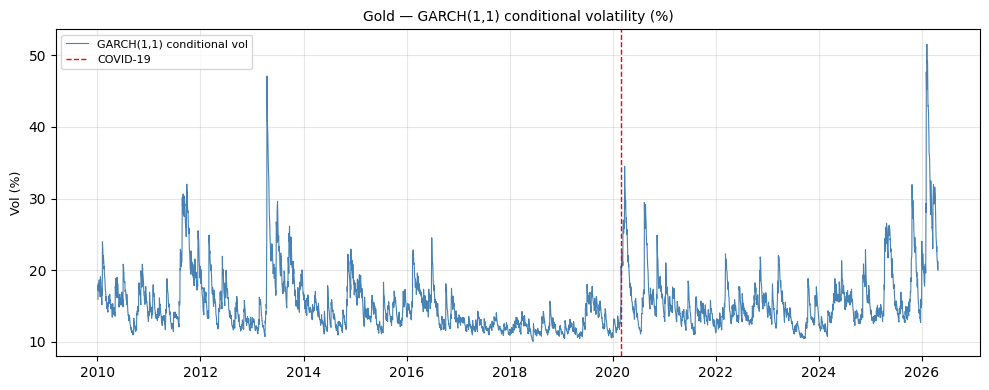

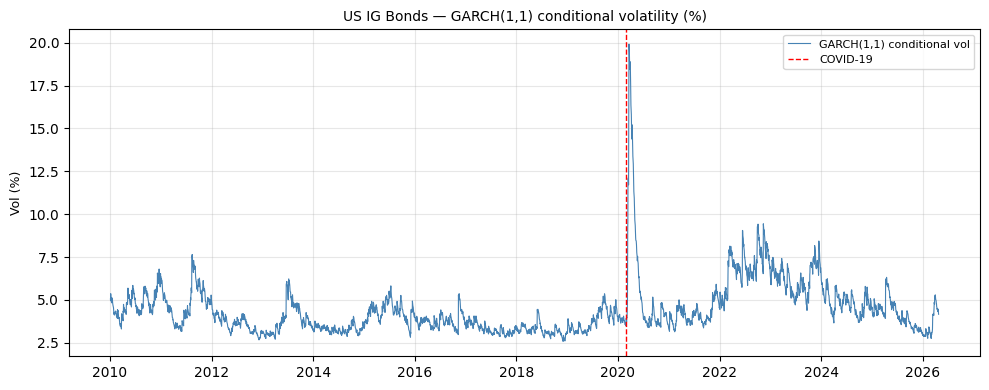

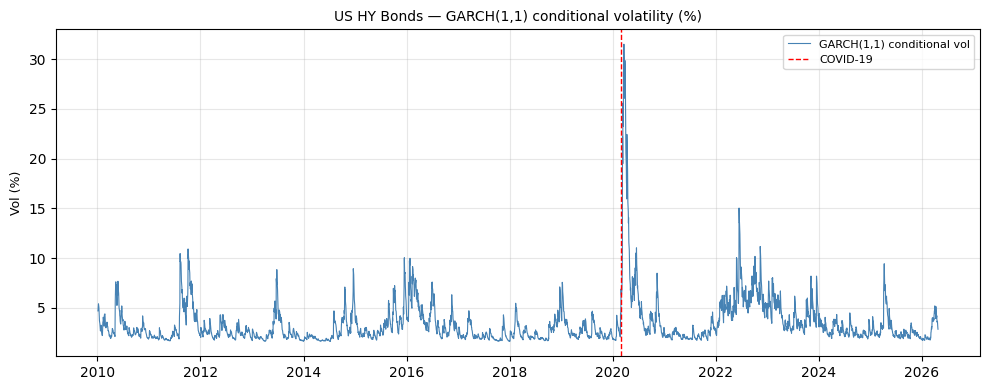

In [205]:
# ── GARCH conditional vol: all assets, panel plot ─────────────────────────
for i, col in enumerate(ASSETS):
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    
    vol = np.sqrt(garch_results[col]['sigma2']) * np.sqrt(ANNUALIZATION) * 100
    ax.plot(vol, linewidth=0.8, color='steelblue', label='GARCH(1,1) conditional vol')
    ax.axvline(COVID_DATE, color='red', linestyle='--', linewidth=1, label='COVID-19')
    ax.set_title(f'{col} — GARCH(1,1) conditional volatility (%)', fontsize=10)
    ax.set_ylabel('Vol (%)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'garch_vol_{col.replace(" ", "_")}.png', dpi=200)
    plt.show()

---
## Section 4 — Dynamic Correlations (DCC)

We implement an EWMA-DCC filter. Univariate volatilities follow EWMA (λ=0.94). The correlation matrix follows the Engle DCC recursion with α=0.02, β=0.97. We then compare key pairwise correlations before and after COVID.

In [206]:
# ── DCC filter ─────────────────────────────────────────────────────────────
def dcc_filter(ret, lam_vol=0.94, alpha=0.02, beta=0.97, burn_in=252):
    X = ret.values.astype(float)
    T, n = X.shape
    mu  = X[:burn_in].mean(axis=0)
    eps = X - mu

    # univariate EWMA variances
    h = np.full((T, n), np.nan)
    h[burn_in - 1] = eps[:burn_in].var(axis=0, ddof=1)
    for t in range(burn_in, T):
        h[t] = lam_vol * h[t-1] + (1 - lam_vol) * eps[t-1]**2

    # standardised residuals
    z = eps / np.sqrt(h)
    z[:burn_in] = np.nan
    Qbar = np.cov(z[burn_in:].T)
    Q = Qbar.copy()

    H_list, R_list, dates = [], [], []
    for t in range(burn_in + 1, T):
        u = z[t-1][:, None]
        Q = (1 - alpha - beta) * Qbar + alpha * (u @ u.T) + beta * Q
        dQ = np.sqrt(np.diag(Q))
        R  = Q / np.outer(dQ, dQ)
        R  = np.clip(R, -0.999, 0.999)
        np.fill_diagonal(R, 1.0)
        D  = np.diag(np.sqrt(h[t]))
        H  = D @ R @ D * ANNUALIZATION
        H_list.append(H)
        R_list.append(R.copy())
        dates.append(ret.index[t])

    return pd.DatetimeIndex(dates), np.array(H_list), np.array(R_list), \
           pd.DataFrame(h, index=ret.index, columns=ret.columns)

dcc_dates, Hs, Rs, h_ewma = dcc_filter(returns)
print(f'DCC filter: {len(dcc_dates):,} observations, {len(ASSETS)} assets')

DCC filter: 4,059 observations, 7 assets


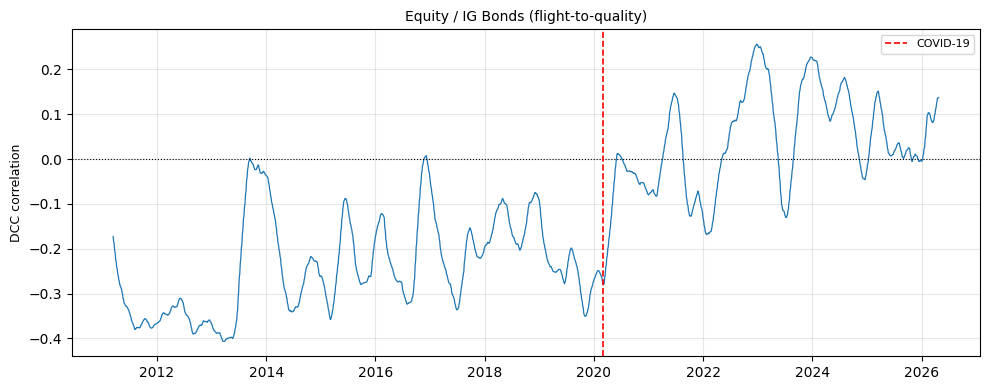

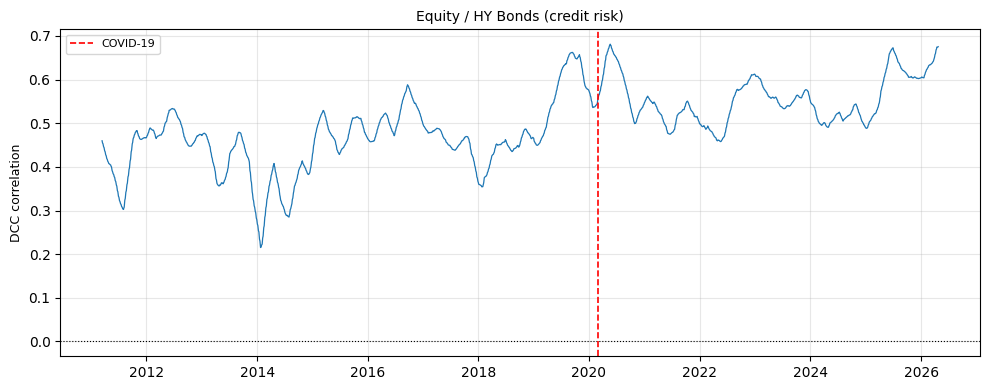

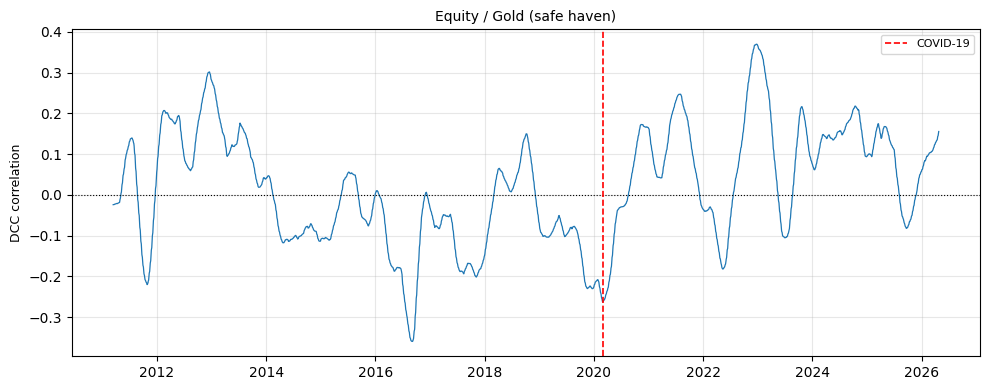

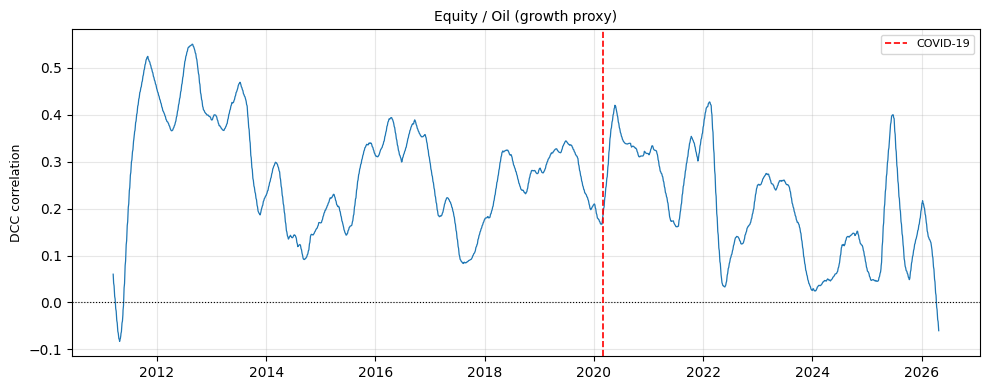

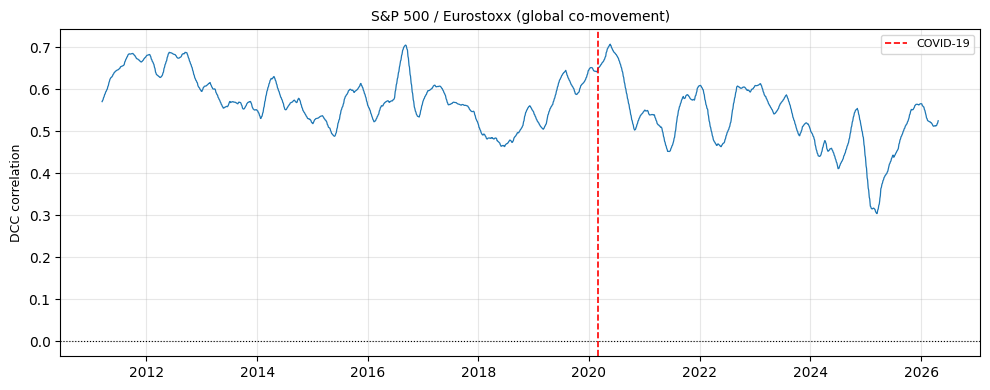

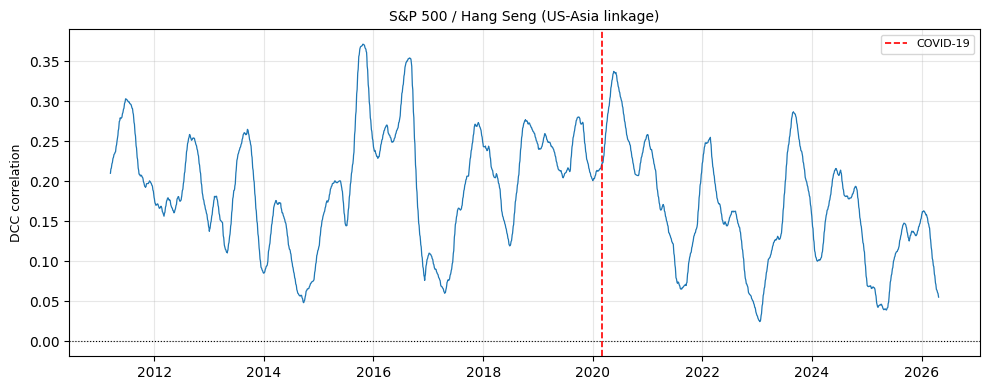

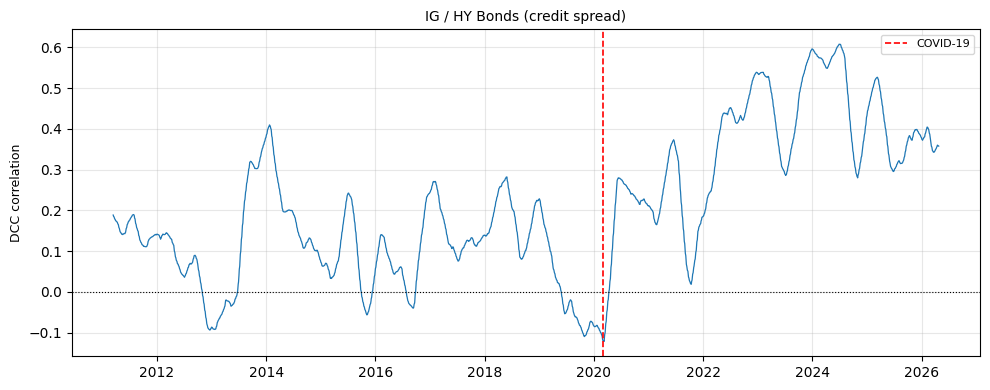

In [207]:
for i, (a1, a2, title) in enumerate(key_pairs):
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    
    corr = get_dcc_corr(a1, a2)
    ax.plot(corr.rolling(63).mean(), linewidth=0.9)
    ax.axhline(0, linestyle=':', linewidth=0.8, color='black')
    ax.axvline(COVID_DATE, color='red', linestyle='--', linewidth=1.2, label='COVID-19')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('DCC correlation', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    safe_name = title.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
    plt.savefig(FIG_DIR / f'dcc_corr_{safe_name}.png', dpi=200)
    plt.show()

In [208]:
# ── Average DCC correlation: pre vs post COVID ─────────────────────────────
corr_table = []
for a1, a2, title in key_pairs:
    c = get_dcc_corr(a1, a2)
    c_pre  = c[c.index <  COVID_DATE].mean()
    c_post = c[c.index >= COVID_DATE].mean()
    corr_table.append({'Pair': title,
                       'Pre-COVID avg corr': round(c_pre,  3),
                       'Post-COVID avg corr': round(c_post, 3),
                       'Change': round(c_post - c_pre, 3)})

corr_df = pd.DataFrame(corr_table).set_index('Pair')
print('Average DCC correlation: pre vs post COVID')
display(corr_df)
corr_df.to_csv(TAB_DIR / 'dcc_corr_pre_post_covid.csv')

Average DCC correlation: pre vs post COVID


,Pre-COVID avg corr,Post-COVID avg corr,Change
Pair,,,
Equity / IG Bonds (flight-to-quality),-0.240,0.049,0.289
Equity / HY Bonds (credit risk),0.461,0.558,0.096
Equity / Gold (safe haven),-0.029,0.093,0.122
Equity / Oil (growth proxy),0.280,0.193,-0.088
S&P 500 / Eurostoxx (global co-movement),0.584,0.524,-0.060
S&P 500 / Hang Seng (US-Asia linkage),0.199,0.156,-0.044
IG / HY Bonds (credit spread),0.106,0.370,0.263


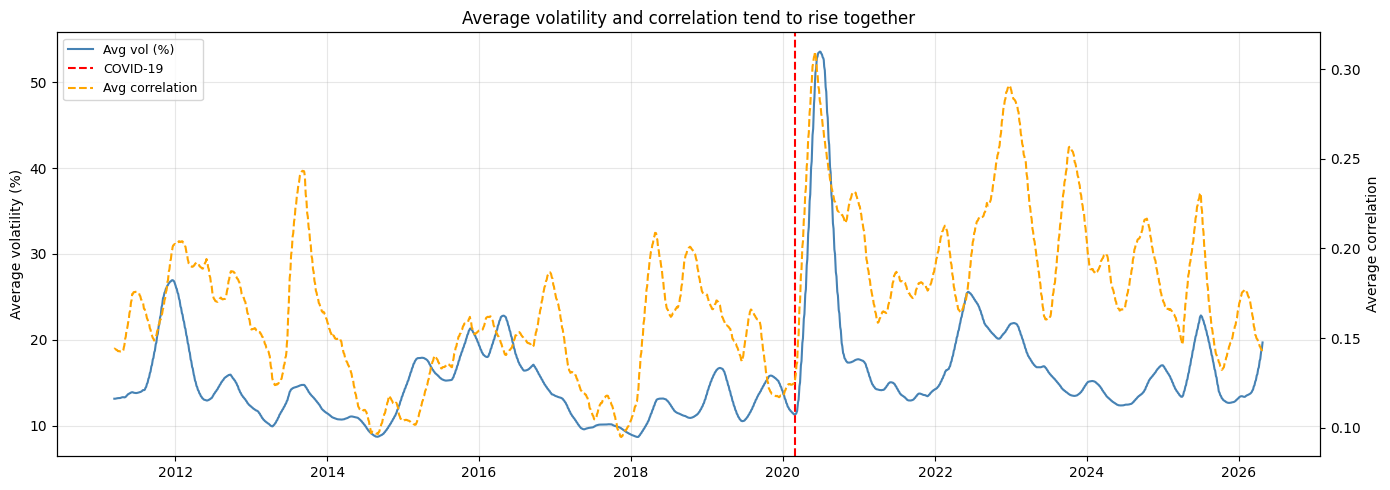

In [209]:
# ── Average cross-asset correlation and average volatility together ─────────
n = len(ASSETS)
avg_corr = pd.Series(
    [Rs[t][np.triu_indices(n, 1)].mean() for t in range(len(Rs))],
    index=dcc_dates, name='Average pairwise DCC correlation'
)
avg_vol = returns.rolling(63).std().mean(axis=1) * np.sqrt(ANNUALIZATION) * 100
avg_vol = avg_vol.reindex(dcc_dates).dropna()
avg_vol.name = 'Average conditional vol (%)'

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(avg_vol.rolling(63).mean(), label='Avg vol (%)', color='steelblue')
ax1.set_ylabel('Average volatility (%)')
ax2 = ax1.twinx()
ax2.plot(avg_corr.rolling(63).mean(), label='Avg correlation', color='orange', linestyle='--')
ax2.set_ylabel('Average correlation')
ax1.axvline(COVID_DATE, color='red', linestyle='--', linewidth=1.5, label='COVID-19')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc='upper left', fontsize=9)
ax1.set_title('Average volatility and correlation tend to rise together')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'avg_vol_corr.png', dpi=200)
plt.show()

---
## Section 5 — Structural Breaks and Regime Analysis

We focus on the equity–bond correlation (S&P 500 vs US IG Bonds) as the central series.  
Two complementary approaches:
1. **Markov-switching** — two latent states (high / low correlation)
2. **Bai-Perron** — structural break dates (permanent shifts)

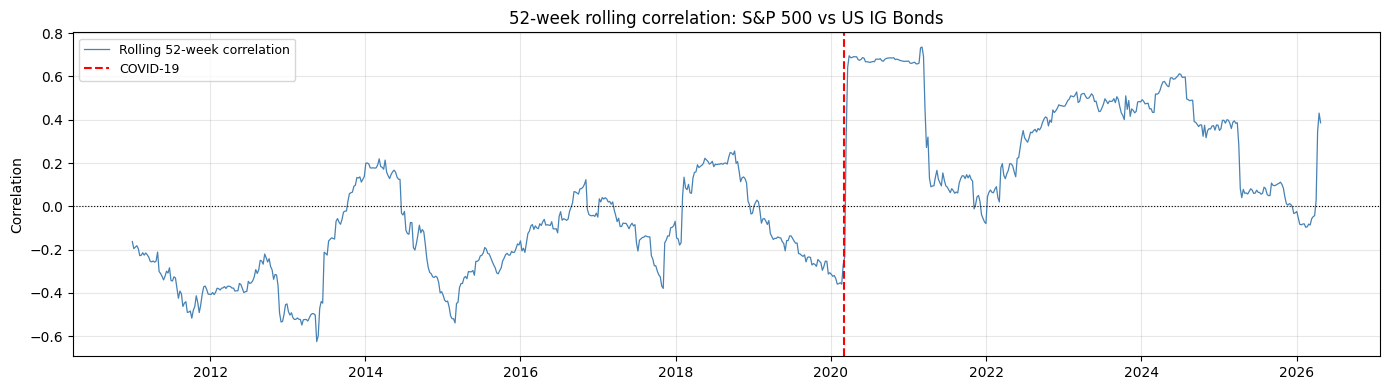

In [210]:
# ── Weekly returns for regime analysis ────────────────────────────────────
weekly_prices  = prices.resample('W-FRI').last().dropna()
weekly_returns = np.log(weekly_prices).diff().dropna()

rolling_corr = (
    weekly_returns['S&P500']
    .rolling(52)
    .corr(weekly_returns['US IG Bonds'])
    .dropna()
)
rolling_corr.name = 'Rolling 52-week corr: S&P 500 vs US IG Bonds'

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rolling_corr, linewidth=0.9, color='steelblue', label='Rolling 52-week correlation')
ax.axhline(0, linestyle=':', linewidth=0.8, color='black')
ax.axvline(COVID_DATE, color='red', linestyle='--', linewidth=1.5, label='COVID-19')
ax.set_title('52-week rolling correlation: S&P 500 vs US IG Bonds')
ax.set_ylabel('Correlation')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rolling_corr_equity_bond.png', dpi=200)
plt.show()

In [211]:
# ── Markov-switching model (2 states) ─────────────────────────────────────
ms_model  = sm.tsa.MarkovRegression(rolling_corr, k_regimes=2, trend='c', switching_variance=True)
ms_result = ms_model.fit(disp=False, maxiter=500)
print(ms_result.summary())

                                     Markov Switching Model Results                                     
Dep. Variable:     Rolling 52-week corr: S&P 500 vs US IG Bonds   No. Observations:                  800
Model:                                         MarkovRegression   Log Likelihood                 190.299
Date:                                          Sat, 16 May 2026   AIC                           -368.597
Time:                                                  21:32:45   BIC                           -340.490
Sample:                                              12-31-2010   HQIC                          -357.800
                                                   - 04-24-2026                                         
Covariance Type:                                         approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
--

In [212]:
# ── Identify high- vs low-correlation state ────────────────────────────────
probs       = ms_result.smoothed_marginal_probabilities
state_means = [(rolling_corr * probs[s]).sum() / probs[s].sum() for s in [0, 1]]
high_state  = int(np.argmax(state_means))
low_state   = 1 - high_state
high_prob   = probs[high_state]
state_high  = (high_prob > 0.5).astype(int)

print(f'State means  — state 0: {state_means[0]:.3f} | state 1: {state_means[1]:.3f}')
print(f'High-correlation state: {high_state}')
print(f'Fraction of time in high-corr state: {state_high.mean():.2%}')

State means  — state 0: -0.236 | state 1: 0.319
High-correlation state: 1
Fraction of time in high-corr state: 49.25%


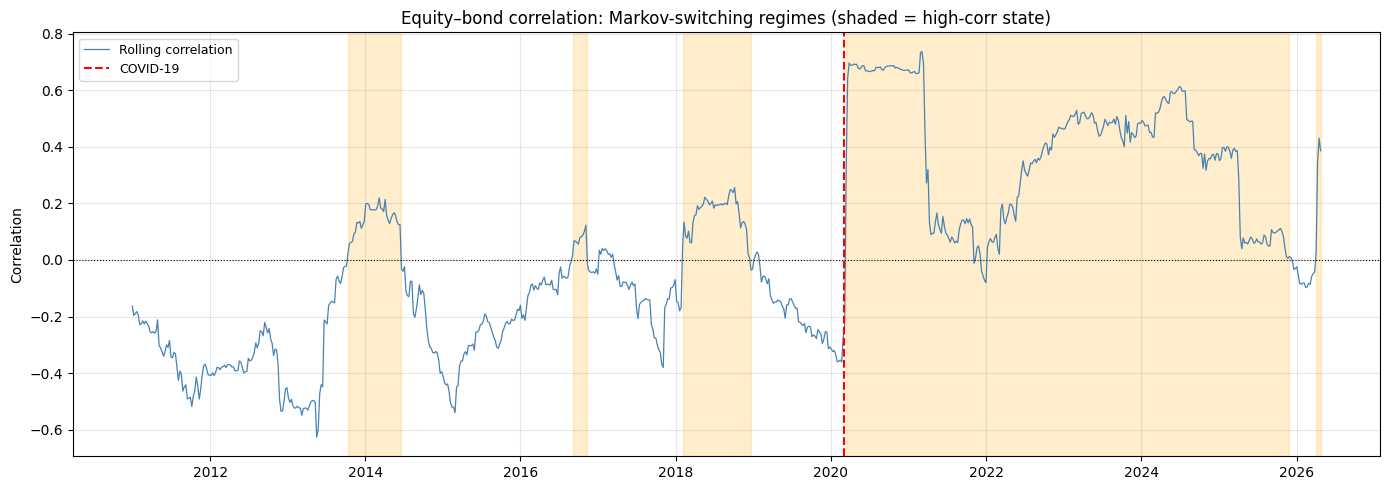

In [213]:
# ── Markov-switching plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
# shade high-correlation regimes
in_regime = False
start = None
for t, val in state_high.items():
    if val == 1 and not in_regime:
        start = t; in_regime = True
    elif val == 0 and in_regime:
        ax.axvspan(start, t, alpha=0.2, color='orange')
        in_regime = False
if in_regime:
    ax.axvspan(start, state_high.index[-1], alpha=0.2, color='orange')

ax.plot(rolling_corr, linewidth=0.9, color='steelblue', label='Rolling correlation')
ax.axhline(0, linestyle=':', linewidth=0.8, color='black')
ax.axvline(COVID_DATE, color='red', linestyle='--', linewidth=1.5, label='COVID-19')
ax.set_title('Equity–bond correlation: Markov-switching regimes (shaded = high-corr state)')
ax.set_ylabel('Correlation')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'markov_switching_regimes.png', dpi=200)
plt.show()

In [214]:
# ── Bai-Perron structural break detection (dynamic programming) ────────────
y       = rolling_corr.values
T       = len(y)
min_seg = 52       # minimum segment length (1 year of weekly data)
n_breaks = 3

cs  = np.r_[0, np.cumsum(y)]
cs2 = np.r_[0, np.cumsum(y * y)]

def segment_sse(i, j):
    n = j - i
    if n <= 0: return np.inf
    sy  = cs[j]  - cs[i]
    sy2 = cs2[j] - cs2[i]
    return sy2 - sy * sy / n

dp   = [None] * (n_breaks + 2)
prev = [None] * (n_breaks + 2)
for segs in range(1, n_breaks + 2):
    d = np.full(T + 1, np.inf)
    p = np.full(T + 1, -1, dtype=int)
    if segs == 1:
        for j in range(min_seg, T + 1):
            d[j] = segment_sse(0, j)
            p[j] = 0
    else:
        prev_d = dp[segs - 1]
        for j in range(segs * min_seg, T + 1):
            for k in range((segs - 1) * min_seg, j - min_seg + 1):
                cost = prev_d[k] + segment_sse(k, j)
                if cost < d[j]:
                    d[j] = cost; p[j] = k
    dp[segs]   = d
    prev[segs] = p

# backtrack
breaks_idx = []
j = T
for segs in range(n_breaks + 1, 0, -1):
    j = prev[segs][j]
    if j > 0: breaks_idx.append(j)
breaks_idx = sorted(breaks_idx)

break_dates = [str(rolling_corr.index[i].date()) for i in breaks_idx]
print('Estimated break dates:', break_dates)

Estimated break dates: ['2013-06-21', '2020-03-13', '2021-03-19']


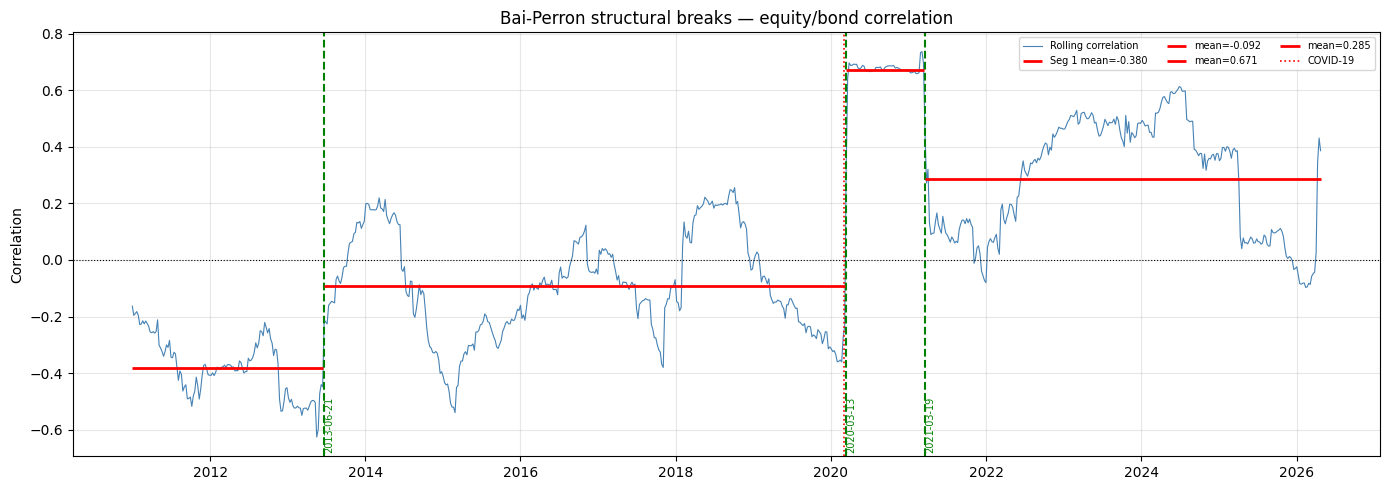

,Segment,Mean correlation
0,2010–2013,-0.380
1,2013–2020,-0.092
2,2020–2021,0.671
3,2021–2026,0.285


In [215]:
# ── Segment means after breaks ─────────────────────────────────────────────
boundaries = [0] + breaks_idx + [T]
seg_means  = [y[boundaries[k]:boundaries[k+1]].mean() for k in range(len(boundaries)-1)]
seg_labels = [f"{rolling_corr.index[boundaries[k]].year}–{rolling_corr.index[boundaries[k+1]-1].year}"
              for k in range(len(boundaries)-1)]

# ── Plot breaks ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_corr, linewidth=0.8, color='steelblue', label='Rolling correlation')

for k, bi in enumerate(breaks_idx):
    bd = rolling_corr.index[bi]
    ax.axvline(bd, color='green', linestyle='--', linewidth=1.5)
    ax.text(bd, ax.get_ylim()[0] + 0.02, str(bd.date()), fontsize=7, color='green', rotation=90)

for k in range(len(boundaries)-1):
    idx_start = rolling_corr.index[boundaries[k]]
    idx_end   = rolling_corr.index[boundaries[k+1]-1]
    ax.hlines(seg_means[k], idx_start, idx_end, colors='red', linewidths=2,
              label=f'Seg {k+1} mean={seg_means[k]:.3f}' if k == 0 else f'mean={seg_means[k]:.3f}')

ax.axvline(COVID_DATE, color='red', linestyle=':', linewidth=1.2, label='COVID-19')
ax.axhline(0, linestyle=':', linewidth=0.8, color='black')
ax.set_title('Bai-Perron structural breaks — equity/bond correlation')
ax.set_ylabel('Correlation')
ax.legend(fontsize=7, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'bai_perron_breaks.png', dpi=200)
plt.show()

break_summary = pd.DataFrame({'Segment': seg_labels, 'Mean correlation': [round(m, 3) for m in seg_means]})
display(break_summary)
break_summary.to_csv(TAB_DIR / 'bai_perron_segment_means.csv', index=False)

---
## Section 6 — ERC Portfolio: Pre vs Post COVID

The Equal Risk Contribution (ERC) portfolio sets weights $w$ such that each asset contributes equally to total portfolio volatility:

$$RC_i = w_i \frac{(\Sigma w)_i}{\sigma_p} = \frac{\sigma_p}{n} \quad \forall i$$

We estimate the rolling ERC on a 2-year window, and compare allocation, risk contributions and performance pre/post COVID.

In [216]:
# ── ERC functions ──────────────────────────────────────────────────────────
def portfolio_vol(w, cov):
    return float(np.sqrt(w @ cov @ w))

def risk_contributions(w, cov):
    sigma   = portfolio_vol(w, cov)
    marginal = cov @ w / sigma
    total    = w * marginal
    percent  = total / sigma
    return total, percent

def erc_weights(cov, start=None):
    n   = cov.shape[0]
    cov = np.asarray(cov, dtype=float)
    cov = (cov + cov.T) / 2
    eig = np.linalg.eigvalsh(cov)
    if eig.min() <= 1e-12:
        cov += np.eye(n) * (1e-8 - eig.min())
    if start is None:
        start = np.repeat(1 / n, n)
    bounds      = [(0, 1)] * n
    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    def obj(w):
        _, pct = risk_contributions(w, cov)
        return np.sum((pct - 1 / n) ** 2)
    res = minimize(obj, start, method='SLSQP', bounds=bounds,
                   constraints=constraints, options={'maxiter': 2000, 'ftol': 1e-12})
    if not res.success:
        res = minimize(obj, np.repeat(1/n, n), method='SLSQP', bounds=bounds,
                       constraints=constraints, options={'maxiter': 3000, 'ftol': 1e-12})
    w = np.maximum(res.x, 0)
    return w / w.sum()

# ── Rolling ERC allocation ─────────────────────────────────────────────────
ROLLING_COV_WINDOW = 252 * 2
month_ends = returns.resample('ME').last().index

weights_list = []
previous = None
for date in month_ends:
    loc = returns.index.searchsorted(date, side='right') - 1
    if loc < ROLLING_COV_WINDOW:
        continue
    cov = returns.iloc[loc - ROLLING_COV_WINDOW + 1: loc + 1].cov().values * ANNUALIZATION
    w   = erc_weights(cov, previous)
    previous = w
    weights_list.append(pd.Series(w, index=ASSETS, name=returns.index[loc]))

erc_weights_df = pd.DataFrame(weights_list)
print(f'ERC computed for {len(erc_weights_df)} months')
erc_weights_df.tail(3)

ERC computed for 173 months


,S&P500,Eurostoxx 50,Hang Seng,Oil futures,Gold,US IG Bonds,US HY Bonds
2026-02-28,0.076088,0.081213,0.056241,0.055090,0.071928,0.333583,0.325856
2026-03-31,0.076283,0.079517,0.056198,0.054236,0.065353,0.336473,0.331938
2026-04-24,0.076112,0.078736,0.056380,0.053220,0.065944,0.338661,0.330946


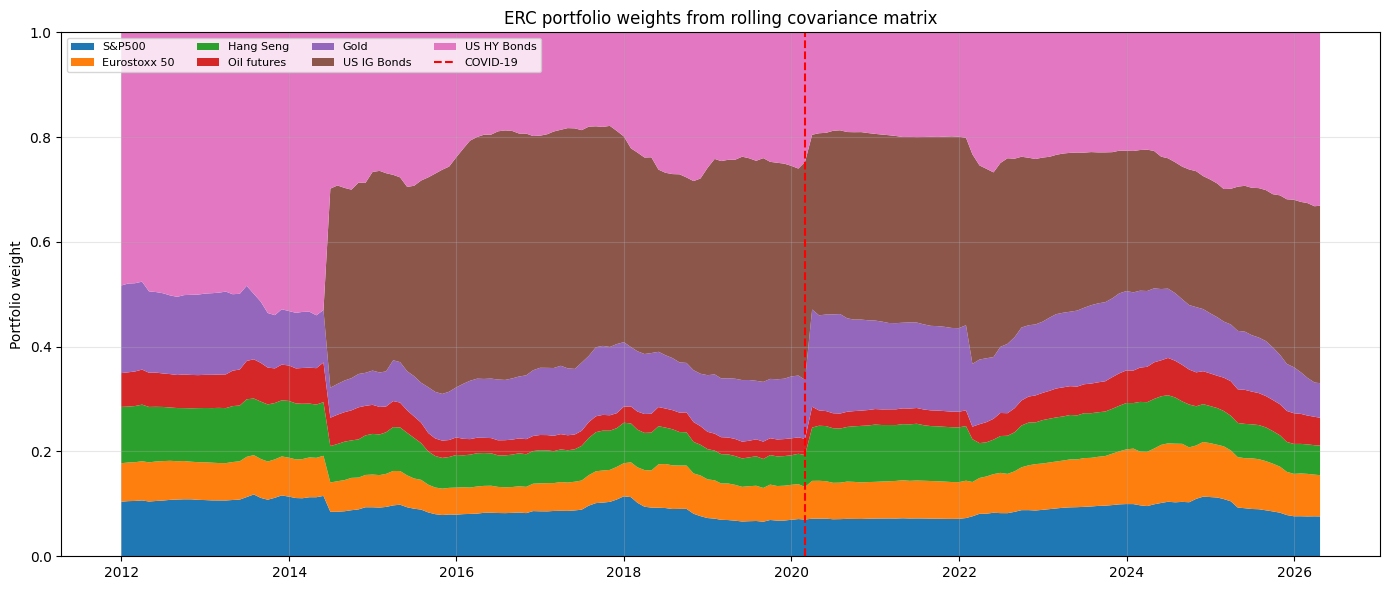

In [217]:
# ── ERC weights stacked area chart ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(erc_weights_df.index,
             [erc_weights_df[a] for a in ASSETS],
             labels=ASSETS)
ax.axvline(COVID_DATE, color='red', linestyle='--', linewidth=1.5, label='COVID-19')
ax.set_title('ERC portfolio weights from rolling covariance matrix')
ax.set_ylabel('Portfolio weight')
ax.set_ylim(0, 1)
ax.legend(loc='upper left', ncol=4, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'erc_weights_stacked.png', dpi=200)
plt.show()

Average ERC weights: pre vs post COVID


,Pre-COVID avg weight,Post-COVID avg weight,Change
S&P500,0.0924,0.0860,-0.0064
Eurostoxx 50,0.0655,0.0856,0.0201
Hang Seng,0.0777,0.0850,0.0073
Oil futures,0.0452,0.0488,0.0035
Gold,0.1145,0.1379,0.0234
US IG Bonds,0.2851,0.3153,0.0301
US HY Bonds,0.3195,0.2414,-0.0781


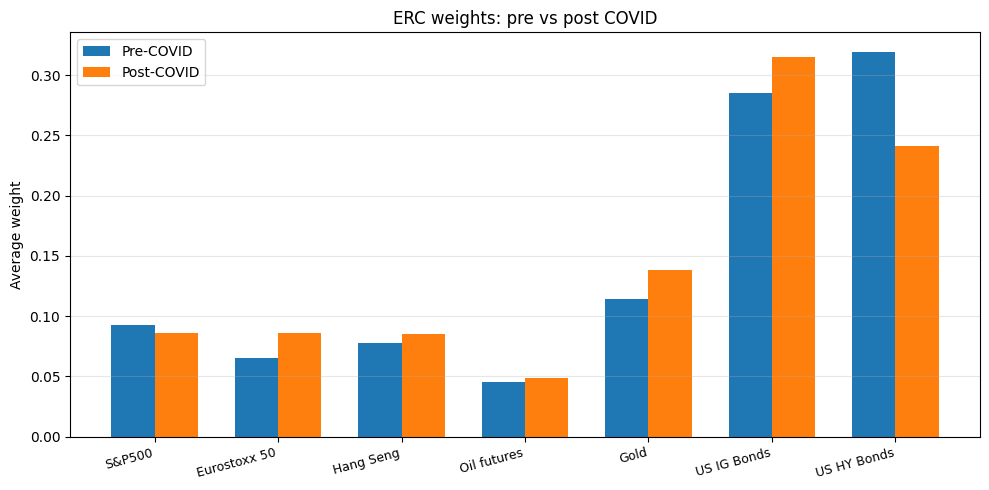

In [218]:
# ── Average ERC weights: pre vs post COVID ─────────────────────────────────
w_pre  = erc_weights_df[erc_weights_df.index <  COVID_DATE].mean()
w_post = erc_weights_df[erc_weights_df.index >= COVID_DATE].mean()
w_compare = pd.DataFrame({'Pre-COVID avg weight': w_pre,
                           'Post-COVID avg weight': w_post,
                           'Change': w_post - w_pre}).round(4)
print('Average ERC weights: pre vs post COVID')
display(w_compare)
w_compare.to_csv(TAB_DIR / 'erc_weights_pre_post_covid.csv')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ASSETS))
width = 0.35
ax.bar(x - width/2, w_pre,  width, label='Pre-COVID')
ax.bar(x + width/2, w_post, width, label='Post-COVID')
ax.set_xticks(x)
ax.set_xticklabels(ASSETS, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Average weight')
ax.set_title('ERC weights: pre vs post COVID')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'erc_weights_bar_pre_post.png', dpi=200)
plt.show()

Portfolio performance: full sample


,Ann. Return (%),Ann. Vol (%),Sharpe,Max Drawdown (%)
ERC,4.976,6.022,0.826,-19.903
Equal Weight,5.121,10.476,0.489,-31.517


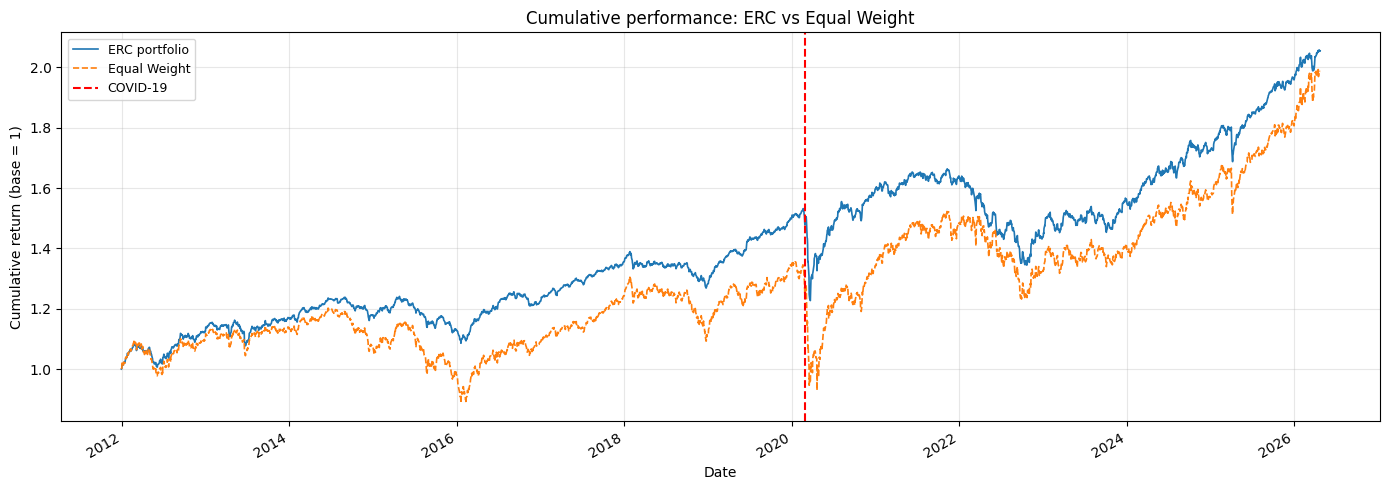

In [219]:
# ── ERC portfolio backtest ─────────────────────────────────────────────────
daily_w    = erc_weights_df.reindex(returns.index, method='ffill').dropna()
common_idx = daily_w.index.intersection(returns.index)
daily_w    = daily_w.loc[common_idx]
ret_common = returns.loc[common_idx]

erc_ret = (daily_w * ret_common).sum(axis=1)
ew_ret  = ret_common.mean(axis=1)   # equal-weight benchmark

erc_cum = (1 + erc_ret).cumprod()
ew_cum  = (1 + ew_ret).cumprod()

def max_drawdown(cum):
    roll_max = cum.cummax()
    return ((cum - roll_max) / roll_max).min()

perf_table = pd.DataFrame({
    'Ann. Return (%)': {
        'ERC': erc_ret.mean() * ANNUALIZATION * 100,
        'Equal Weight': ew_ret.mean() * ANNUALIZATION * 100
    },
    'Ann. Vol (%)': {
        'ERC': erc_ret.std() * np.sqrt(ANNUALIZATION) * 100,
        'Equal Weight': ew_ret.std() * np.sqrt(ANNUALIZATION) * 100
    },
    'Sharpe': {
        'ERC': (erc_ret.mean() * ANNUALIZATION) / (erc_ret.std() * np.sqrt(ANNUALIZATION)),
        'Equal Weight': (ew_ret.mean() * ANNUALIZATION) / (ew_ret.std() * np.sqrt(ANNUALIZATION))
    },
    'Max Drawdown (%)': {
        'ERC': max_drawdown(erc_cum) * 100,
        'Equal Weight': max_drawdown(ew_cum) * 100
    }
}).round(3)

print('Portfolio performance: full sample')
display(perf_table)
perf_table.to_csv(TAB_DIR / 'portfolio_performance_full.csv')

fig, ax = plt.subplots(figsize=(14, 5))
erc_cum.plot(ax=ax, label='ERC portfolio', linewidth=1.2)
ew_cum.plot(ax=ax,  label='Equal Weight',  linewidth=1.2, linestyle='--')
ax.axvline(COVID_DATE, color='red', linestyle='--', linewidth=1.5, label='COVID-19')
ax.set_title('Cumulative performance: ERC vs Equal Weight')
ax.set_ylabel('Cumulative return (base = 1)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'portfolio_cumulative_perf.png', dpi=200)
plt.show()

In [220]:
# ── Performance split: pre vs post COVID ──────────────────────────────────
def perf_stats(ret_series, label):
    ann_ret = ret_series.mean() * ANNUALIZATION * 100
    ann_vol = ret_series.std()  * np.sqrt(ANNUALIZATION) * 100
    sharpe  = (ret_series.mean() * ANNUALIZATION) / (ret_series.std() * np.sqrt(ANNUALIZATION))
    mdd     = max_drawdown((1 + ret_series).cumprod()) * 100
    return {'Portfolio': label,
            'Ann. Return (%)': round(ann_ret, 2),
            'Ann. Vol (%)':    round(ann_vol, 2),
            'Sharpe':          round(sharpe,  2),
            'Max DD (%)':      round(mdd,      2)}

rows = [
    perf_stats(erc_ret[erc_ret.index <  COVID_DATE], 'ERC Pre-COVID'),
    perf_stats(erc_ret[erc_ret.index >= COVID_DATE], 'ERC Post-COVID'),
    perf_stats(ew_ret[ew_ret.index   <  COVID_DATE], 'EW Pre-COVID'),
    perf_stats(ew_ret[ew_ret.index   >= COVID_DATE], 'EW Post-COVID'),
]
perf_split = pd.DataFrame(rows).set_index('Portfolio')
print('Portfolio performance: pre vs post COVID')
display(perf_split)
perf_split.to_csv(TAB_DIR / 'portfolio_performance_split.csv')

Portfolio performance: pre vs post COVID


,Ann. Return (%),Ann. Vol (%),Sharpe,Max DD (%)
Portfolio,,,,
ERC Pre-COVID,4.67,4.59,1.02,-12.52
ERC Post-COVID,5.39,7.51,0.72,-19.12
EW Pre-COVID,2.87,8.28,0.35,-26.25
EW Post-COVID,8.11,12.82,0.63,-27.16


---
## Section 7 — DCC Betas

For portfolio weights $w_t$, the conditional beta of the ERC portfolio to asset $j$ is:

$$\beta_{p|j,t} = \frac{\text{Cov}_t(r_p, r_j)}{\text{Var}_t(r_j)} = \frac{w_t' H_t e_j}{h_{jj,t}}$$

This measures how the portfolio co-moves with each asset under the DCC covariance matrix.

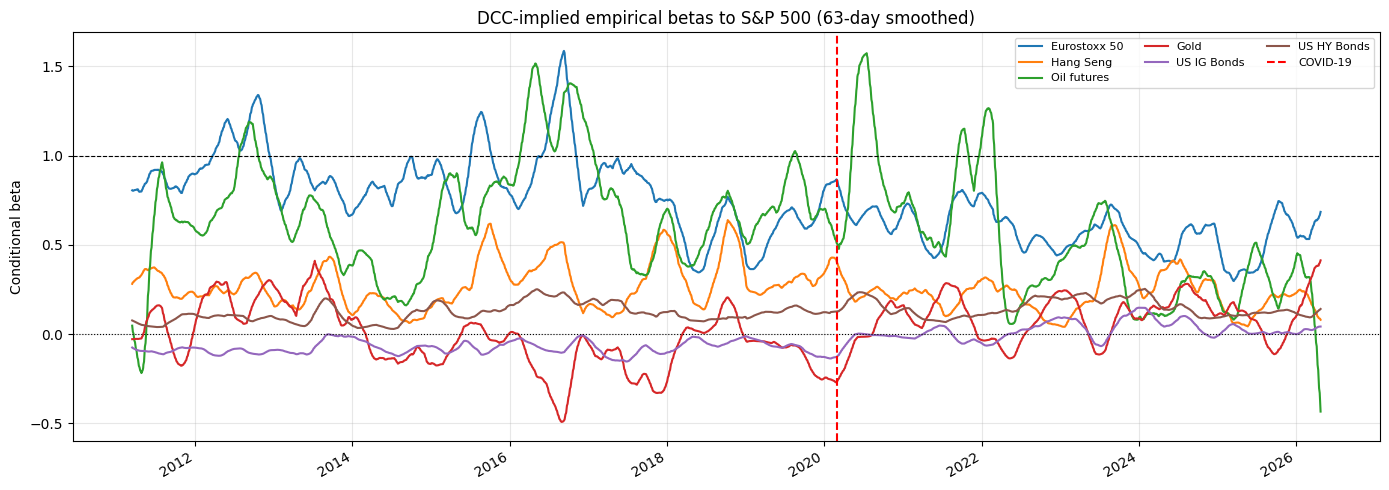

In [221]:
# ── DCC betas of each asset to S&P 500 ────────────────────────────────────
m = ASSETS.index('S&P500')
betas_to_sp500 = pd.DataFrame(
    {ASSETS[i]: Hs[:, i, m] / Hs[:, m, m] for i in range(len(ASSETS))},
    index=dcc_dates
)

fig, ax = plt.subplots(figsize=(14, 5))
selected = [a for a in ASSETS if a != 'S&P500']
betas_to_sp500[selected].rolling(63).mean().plot(ax=ax)
ax.axhline(1, linestyle='--', linewidth=0.8, color='black')
ax.axhline(0, linestyle=':', linewidth=0.8, color='black')
ax.axvline(COVID_DATE, color='red', linestyle='--', linewidth=1.5, label='COVID-19')
ax.set_title('DCC-implied empirical betas to S&P 500 (63-day smoothed)')
ax.set_ylabel('Conditional beta')
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'dcc_betas_to_sp500.png', dpi=200)
plt.show()

In [222]:
# ── Beta summary: pre vs post COVID ────────────────────────────────────────
beta_pre  = betas_to_sp500[betas_to_sp500.index <  COVID_DATE]
beta_post = betas_to_sp500[betas_to_sp500.index >= COVID_DATE]

beta_summary = pd.DataFrame({
    'Pre-COVID avg beta' : beta_pre.mean().round(3),
    'Post-COVID avg beta': beta_post.mean().round(3),
    'Change'             : (beta_post.mean() - beta_pre.mean()).round(3)
})
print('DCC beta to S&P 500: pre vs post COVID')
display(beta_summary)
beta_summary.to_csv(TAB_DIR / 'dcc_betas_pre_post_covid.csv')

DCC beta to S&P 500: pre vs post COVID


,Pre-COVID avg beta,Post-COVID avg beta,Change
S&P500,1.000,1.000,0.000
Eurostoxx 50,0.840,0.573,-0.267
Hang Seng,0.283,0.224,-0.059
Oil futures,0.676,0.465,-0.212
Gold,-0.029,0.105,0.134
US IG Bonds,-0.077,0.023,0.101
US HY Bonds,0.117,0.149,0.032


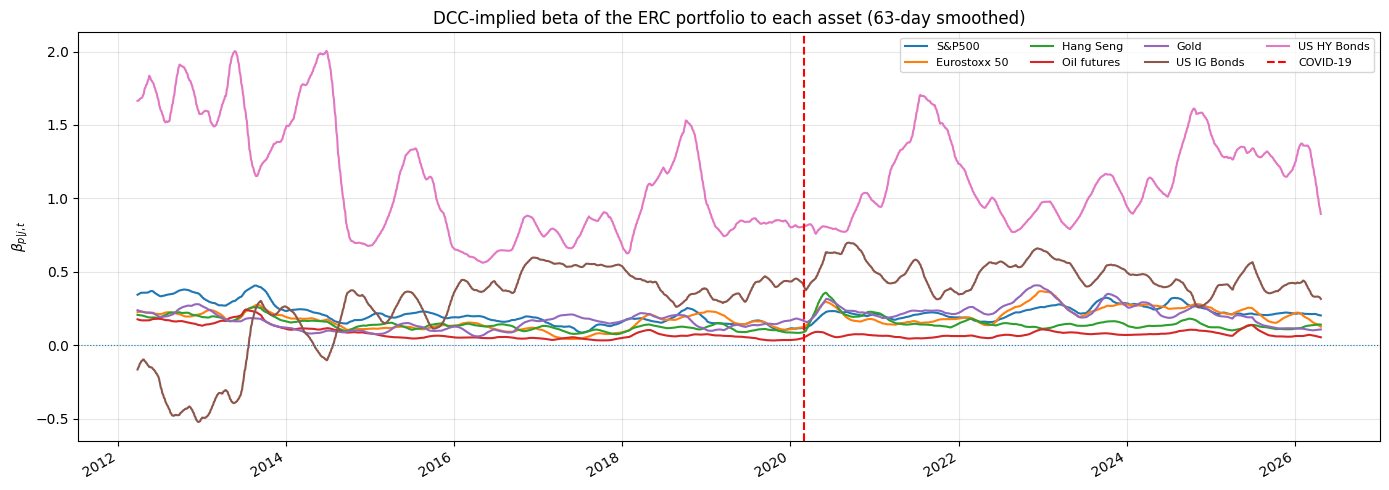

ERC portfolio betas to each asset


,Average beta,Pre-COVID,Post-COVID,Latest
S&P500,0.218,0.210,0.229,0.180
Eurostoxx 50,0.182,0.153,0.221,0.102
Hang Seng,0.146,0.140,0.153,0.120
Oil futures,0.082,0.088,0.074,0.032
Gold,0.186,0.152,0.231,0.122
US IG Bonds,0.334,0.229,0.474,0.349
US HY Bonds,1.117,1.112,1.125,0.686


In [223]:
# ── ERC portfolio betas to each asset ─────────────────────────────────────
daily_w2    = erc_weights_df.reindex(returns.index, method='ffill')
daily_w2    = daily_w2.loc[dcc_dates].ffill().dropna()
mask        = np.isin(dcc_dates, daily_w2.index)
H_aligned   = Hs[mask]
dates_align = dcc_dates[mask]
W           = daily_w2.loc[dates_align].values

erc_betas = []
for k, H in enumerate(H_aligned):
    w           = W[k]
    cov_p_assets = w @ H
    beta_p       = cov_p_assets / np.diag(H)
    erc_betas.append(beta_p)

erc_betas_df = pd.DataFrame(erc_betas, index=dates_align, columns=ASSETS)

fig, ax = plt.subplots(figsize=(14, 5))
erc_betas_df.rolling(63).mean().plot(ax=ax)
ax.axhline(0, linestyle=':', linewidth=0.8)
ax.axvline(COVID_DATE, color='red', linestyle='--', linewidth=1.5, label='COVID-19')
ax.set_title('DCC-implied beta of the ERC portfolio to each asset (63-day smoothed)')
ax.set_ylabel(r'$\beta_{p|j,t}$')
ax.legend(fontsize=8, ncol=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'erc_portfolio_betas.png', dpi=200)
plt.show()

erc_beta_summary = pd.DataFrame({
    'Average beta': erc_betas_df.mean().round(3),
    'Pre-COVID':    erc_betas_df[erc_betas_df.index <  COVID_DATE].mean().round(3),
    'Post-COVID':   erc_betas_df[erc_betas_df.index >= COVID_DATE].mean().round(3),
    'Latest':       erc_betas_df.iloc[-1].round(3)
})
print('ERC portfolio betas to each asset')
display(erc_beta_summary)
erc_beta_summary.to_csv(TAB_DIR / 'erc_portfolio_betas_summary.csv')

---
## Section 8 — Summary of Results

This section assembles the key empirical findings across all dimensions to support the conclusion of the report.

In [224]:
# ── Master summary table ───────────────────────────────────────────────────
print('=== SUMMARY: Has the structure of risk changed since COVID-19? ===\n')

print('1. VOLATILITY (GARCH)')
display(vol_compare)

print('\n2. DYNAMIC CORRELATIONS (DCC)')
display(corr_df)

print('\n3. STRUCTURAL BREAKS (Bai-Perron)')
display(break_summary)

print('\n4. ERC WEIGHTS')
display(w_compare)

print('\n5. PORTFOLIO PERFORMANCE')
display(perf_split)

print('\n6. DCC BETAS TO S&P 500')
display(beta_summary)

=== SUMMARY: Has the structure of risk changed since COVID-19? ===

1. VOLATILITY (GARCH)


,Pre-COVID avg vol (%),Post-COVID avg vol (%),Change (pp)
S&P500,15.32,19.24,3.92
Eurostoxx 50,19.10,19.57,0.47
Hang Seng,18.54,22.95,4.41
Oil futures,31.60,49.85,18.25
Gold,15.28,16.94,1.66
US IG Bonds,3.96,5.68,1.72
US HY Bonds,3.32,5.28,1.96



2. DYNAMIC CORRELATIONS (DCC)


,Pre-COVID avg corr,Post-COVID avg corr,Change
Pair,,,
Equity / IG Bonds (flight-to-quality),-0.240,0.049,0.289
Equity / HY Bonds (credit risk),0.461,0.558,0.096
Equity / Gold (safe haven),-0.029,0.093,0.122
Equity / Oil (growth proxy),0.280,0.193,-0.088
S&P 500 / Eurostoxx (global co-movement),0.584,0.524,-0.060
S&P 500 / Hang Seng (US-Asia linkage),0.199,0.156,-0.044
IG / HY Bonds (credit spread),0.106,0.370,0.263



3. STRUCTURAL BREAKS (Bai-Perron)


...

,Pre-COVID avg weight,Post-COVID avg weight,Change
S&P500,0.0924,0.0860,-0.0064
Eurostoxx 50,0.0655,0.0856,0.0201
Hang Seng,0.0777,0.0850,0.0073
Oil futures,0.0452,0.0488,0.0035
Gold,0.1145,0.1379,0.0234
US IG Bonds,0.2851,0.3153,0.0301
US HY Bonds,0.3195,0.2414,-0.0781



5. PORTFOLIO PERFORMANCE


,Ann. Return (%),Ann. Vol (%),Sharpe,Max DD (%)
Portfolio,,,,
ERC Pre-COVID,4.67,4.59,1.02,-12.52
ERC Post-COVID,5.39,7.51,0.72,-19.12
EW Pre-COVID,2.87,8.28,0.35,-26.25
EW Post-COVID,8.11,12.82,0.63,-27.16



6. DCC BETAS TO S&P 500


,Pre-COVID avg beta,Post-COVID avg beta,Change
S&P500,1.000,1.000,0.000
Eurostoxx 50,0.840,0.573,-0.267
Hang Seng,0.283,0.224,-0.059
Oil futures,0.676,0.465,-0.212
Gold,-0.029,0.105,0.134
US IG Bonds,-0.077,0.023,0.101
US HY Bonds,0.117,0.149,0.032
